In [1]:
'''
#step0.0 logging all runs
import os
import sys
import logging
from datetime import datetime

# ADDED: Define your logs folder (adjust path as needed)
LOGS_DIR = "/home/maryam_s/Documents/GPU SAM/segment_anything/logs"
os.makedirs(LOGS_DIR, exist_ok=True)

# ADDED: Create a timestamp for the current run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_file = os.path.join(LOGS_DIR, f"experiment_log_{timestamp}.log")

# ADDED: Get the root logger and clear existing handlers
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)  # Capture all messages to file

# Remove any existing handlers
for handler in logger.handlers[:]:
    logger.removeHandler(handler)

# ADDED: Create FileHandler for all messages (DEBUG and above)
file_handler = logging.FileHandler(log_file)
file_handler.setLevel(logging.DEBUG)
file_formatter = logging.Formatter('%(asctime)s %(levelname)s: %(message)s')
file_handler.setFormatter(file_formatter)
logger.addHandler(file_handler)

# ADDED: Create a ConsoleHandler that shows INFO and above
# (This one uses sys.__stdout__ so it writes directly to the console)
console_handler = logging.StreamHandler(sys.__stdout__)
console_handler.setLevel(logging.INFO)
console_formatter = logging.Formatter('%(levelname)s: %(message)s')
console_handler.setFormatter(console_formatter)
logger.addHandler(console_handler)

# ADDED: Create a DualStream that writes to both original stdout and logger.
class DualStream:
    def __init__(self, logger, stream, log_level=logging.INFO):
        self.logger = logger
        self.stream = stream  # this is the original sys.__stdout__
        self.log_level = log_level

    def write(self, message):
        # Write to the original stream
        self.stream.write(message)
        # And also log non-empty lines to the logger
        if message.strip():
            self.logger.log(self.log_level, message.strip())

    def flush(self):
        self.stream.flush()

# ADDED: Set sys.stdout to the DualStream so print() calls go both to the console and the logger.
sys.stdout = DualStream(logger, sys.__stdout__, logging.INFO)
# You can choose whether to also override stderr; here we do it for errors:
sys.stderr = DualStream(logger, sys.__stderr__, logging.ERROR)

# ADDED: Initial logging messages
logger.info("Starting experiment run...")
logger.debug("This debug message will appear only in the log file.")
logger.info("This info message will appear in both the log file and the console.")

# ADDED: Append an entry to your experiment changelog markdown file.
changelog_file = os.path.join(LOGS_DIR, "experiment_changelog.md")
with open(changelog_file, "a") as f:
    f.write(f"\n### {timestamp}\n")
    f.write("- **Change:** [Describe the change here: e.g., Integrated amplitude embedding in the quantum attention module]\n")
    f.write("- **Code Change:** [Describe what was modified]\n")
    f.write("- **Files Affected:** `Documents/GPU SAM/segment_anything/notebooks/SQ1-GPU.ipynb`\n")
    f.write("- **Notes:** [Any additional notes about the run]\n")
    f.write(f"- **Log File:** `{log_file}`\n")

logger.info("Experiment setup complete. Log file created at: %s", log_file)
'''

'\n#step0.0 logging all runs\nimport os\nimport sys\nimport logging\nfrom datetime import datetime\n\n# ADDED: Define your logs folder (adjust path as needed)\nLOGS_DIR = "/home/maryam_s/Documents/GPU SAM/segment_anything/logs"\nos.makedirs(LOGS_DIR, exist_ok=True)\n\n# ADDED: Create a timestamp for the current run\ntimestamp = datetime.now().strftime("%Y%m%d_%H%M%S")\nlog_file = os.path.join(LOGS_DIR, f"experiment_log_{timestamp}.log")\n\n# ADDED: Get the root logger and clear existing handlers\nlogger = logging.getLogger()\nlogger.setLevel(logging.DEBUG)  # Capture all messages to file\n\n# Remove any existing handlers\nfor handler in logger.handlers[:]:\n    logger.removeHandler(handler)\n\n# ADDED: Create FileHandler for all messages (DEBUG and above)\nfile_handler = logging.FileHandler(log_file)\nfile_handler.setLevel(logging.DEBUG)\nfile_formatter = logging.Formatter(\'%(asctime)s %(levelname)s: %(message)s\')\nfile_handler.setFormatter(file_formatter)\nlogger.addHandler(file_han

In [2]:
#step0
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"  # Use a writable temporary directory
os.environ["MPLBACKEND"] = "agg"  # Use a non-interactive backend that’s supported

In [3]:
#step1: Install Required Packages
#!pip install opencv-python pycocotools tqdm matplotlib
#!pip install git+https://github.com/facebookresearch/segment-anything.git

In [4]:
# Step 1.1: Central Configuration: Dynamic Paths & HOME
import os

# The absolute folder where you want to store all shapes datasets
SHAPES_FOLDER_ABS = "/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes"

# For naming: We can still do something like "shapes_dataset_80x80_50imgs"
# but the generate_dataset function will handle the final name.

# We'll store the final chosen dataset name in a variable if needed.
# For example, if you want 80x80 with 50 images:
IMG_WIDTH = 80
IMG_HEIGHT = 80
NUM_IMAGES = 50

# Let's define a base name
BASE_DATASET_NAME = "shapes_dataset"

# We'll not define DATASET_NAME manually. We'll let the generate_dataset function do it.
# We'll store the final path returned by generate_dataset into a variable:
DATASET_PATH = None

# (Optionally define your HOME env var)
os.environ["HOME"] = "/home/maryam_s/Documents/GPU SAM/segment-anything/notebooks/SQ1-GPU"
print("HOME is now:", os.environ["HOME"])

HOME is now: /home/maryam_s/Documents/GPU SAM/segment-anything/notebooks/SQ1-GPU


In [5]:
#step2 generation of dataset
import subprocess
import os
from datetime import datetime

def generate_dataset(num_images, img_width, img_height, shapes_folder, base_dataset_name="shapes_dataset"):
    """
    Generates a shapes dataset with the given resolution and number of images.
    If the dataset already exists, it will be reused.
    
    The dataset is stored under SHAPES_FOLDER_ABS/<base_dataset_name>_<img_width>x<img_height>_<num_images>imgs.
    """
    # 1) The absolute folder where we want the dataset to reside:
    SHAPES_FOLDER_ABS = "/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes"

    # 2) Unique dataset folder name, e.g. "shapes_dataset_80x80_50imgs"
    dataset_name = f"{base_dataset_name}_{img_width}x{img_height}_{num_images}imgs"

    # 3) Build the absolute save_dir
    save_dir = os.path.join(SHAPES_FOLDER_ABS, dataset_name)

    # 4) Check if folder already exists
    if os.path.exists(save_dir) and os.path.isdir(save_dir):
        print(f"[INFO] Dataset already exists at: {os.path.abspath(save_dir)}. Reusing existing dataset.")
        return os.path.abspath(save_dir)

    # 5) Otherwise, create it and run the shapes script
    os.makedirs(save_dir, exist_ok=True)
    print(f"[INFO] Generating new dataset at: {os.path.abspath(save_dir)}")

    command = [
        "python", "run.py",
        "--save_dir", save_dir,
        "--task_type", "detection",
        "--num_images", str(num_images),
        "--image_size", str(img_width), str(img_height),
        "--shapes", "circle", "rect",
        "--shape_color", "blue",
        "--shuffle_color", "False"
    ]

    # The 'shapes_folder' is the location of run.py script
    result = subprocess.run(command, cwd=shapes_folder, capture_output=True, text=True)

    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)
    print(f"[INFO] Dataset generated at: {os.path.abspath(save_dir)}")
    print("Check subfolders like 'images' and 'labels_json' within it...")

    return os.path.abspath(save_dir)

# 6) Now we actually call it, specifying the local shapes folder that has run.py:
SHAPES_FOLDER_LOCAL = "shapes"  # or wherever your run.py is.

# We'll store the returned path in DATASET_PATH
DATASET_PATH = generate_dataset(NUM_IMAGES, IMG_WIDTH, IMG_HEIGHT, SHAPES_FOLDER_LOCAL, base_dataset_name=BASE_DATASET_NAME)
print("Dataset path to be used:", DATASET_PATH)


[INFO] Dataset already exists at: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs. Reusing existing dataset.
Dataset path to be used: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs


In [6]:
# MODIFY: Use the central configuration for dataset path.
!ls -R "{DATASET_PATH}"  # CHANGE: Now lists the dynamic dataset folder

'/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs':
coco_annotations.json  images  labels_json

'/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/images':
shapes_0.png   shapes_18.png  shapes_27.png  shapes_36.png  shapes_45.png
shapes_1.png   shapes_19.png  shapes_28.png  shapes_37.png  shapes_46.png
shapes_10.png  shapes_2.png   shapes_29.png  shapes_38.png  shapes_47.png
shapes_11.png  shapes_20.png  shapes_3.png   shapes_39.png  shapes_48.png
shapes_12.png  shapes_21.png  shapes_30.png  shapes_4.png   shapes_49.png
shapes_13.png  shapes_22.png  shapes_31.png  shapes_40.png  shapes_5.png
shapes_14.png  shapes_23.png  shapes_32.png  shapes_41.png  shapes_6.png
shapes_15.png  shapes_24.png  shapes_33.png  shapes_42.png  shapes_7.png
shapes_16.png  shapes_25.png  shapes_34.png  shapes_43.png  shapes_8.png
shapes_17.png  shapes_26.png  shapes_35.png  shapes_44.png  shapes_9.png

'/home/maryam_s/D

In [7]:
# Step 3: Visualize bounding boxes ...
# We'll define your DATASET_IMAGES and DATASET_LABELS using DATASET_PATH

DATASET_IMAGES = os.path.join(DATASET_PATH, "images")
DATASET_LABELS = os.path.join(DATASET_PATH, "labels_json")

print("DATASET_IMAGES:", DATASET_IMAGES)
print("DATASET_LABELS:", DATASET_LABELS)

DATASET_IMAGES: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/images
DATASET_LABELS: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/labels_json


Image: shapes_0.png
Label: shapes_0.json


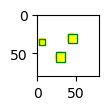

Image: shapes_1.png
Label: shapes_1.json


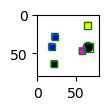

Image: shapes_10.png
Label: shapes_10.json


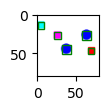

Image: shapes_11.png
Label: shapes_11.json


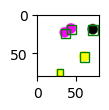

Image: shapes_12.png
Label: shapes_12.json


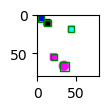

Image: shapes_13.png
Label: shapes_13.json


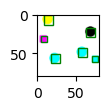

Image: shapes_14.png
Label: shapes_14.json


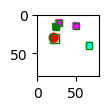

Image: shapes_15.png
Label: shapes_15.json


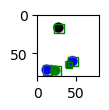

Image: shapes_16.png
Label: shapes_16.json


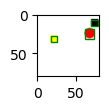

Image: shapes_17.png
Label: shapes_17.json


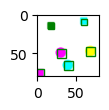

Image: shapes_18.png
Label: shapes_18.json


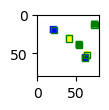

Image: shapes_19.png
Label: shapes_19.json


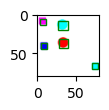

Image: shapes_2.png
Label: shapes_2.json


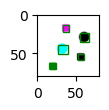

Image: shapes_20.png
Label: shapes_20.json


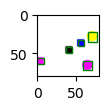

Image: shapes_21.png
Label: shapes_21.json


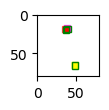

Image: shapes_22.png
Label: shapes_22.json


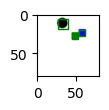

Image: shapes_23.png
Label: shapes_23.json


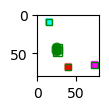

Image: shapes_24.png
Label: shapes_24.json


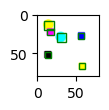

Image: shapes_25.png
Label: shapes_25.json


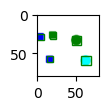

Image: shapes_26.png
Label: shapes_26.json


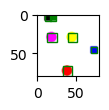

Image: shapes_27.png
Label: shapes_27.json


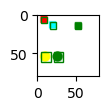

Image: shapes_28.png
Label: shapes_28.json


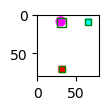

Image: shapes_29.png
Label: shapes_29.json


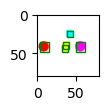

Image: shapes_3.png
Label: shapes_3.json


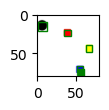

Image: shapes_30.png
Label: shapes_30.json


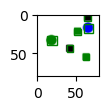

Image: shapes_31.png
Label: shapes_31.json


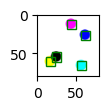

Image: shapes_32.png
Label: shapes_32.json


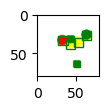

Image: shapes_33.png
Label: shapes_33.json


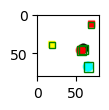

Image: shapes_34.png
Label: shapes_34.json


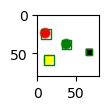

Image: shapes_35.png
Label: shapes_35.json


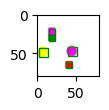

Image: shapes_36.png
Label: shapes_36.json


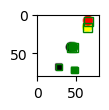

Image: shapes_37.png
Label: shapes_37.json


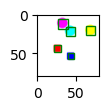

Image: shapes_38.png
Label: shapes_38.json


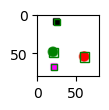

Image: shapes_39.png
Label: shapes_39.json


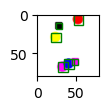

Image: shapes_4.png
Label: shapes_4.json


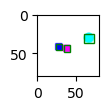

Image: shapes_40.png
Label: shapes_40.json


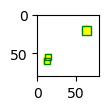

Image: shapes_41.png
Label: shapes_41.json


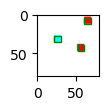

Image: shapes_42.png
Label: shapes_42.json


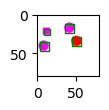

Image: shapes_43.png
Label: shapes_43.json


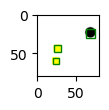

Image: shapes_44.png
Label: shapes_44.json


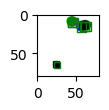

Image: shapes_45.png
Label: shapes_45.json


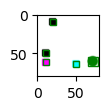

Image: shapes_46.png
Label: shapes_46.json


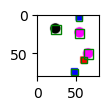

Image: shapes_47.png
Label: shapes_47.json


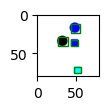

Image: shapes_48.png
Label: shapes_48.json


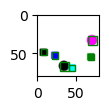

Image: shapes_49.png
Label: shapes_49.json


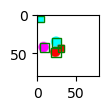

Image: shapes_5.png
Label: shapes_5.json


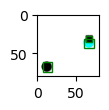

Image: shapes_6.png
Label: shapes_6.json


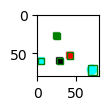

Image: shapes_7.png
Label: shapes_7.json


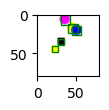

Image: shapes_8.png
Label: shapes_8.json


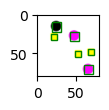

Image: shapes_9.png
Label: shapes_9.json


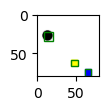

In [8]:
#step3.1: visualization for step 3
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import os

def json_listing(json_data):
    label = []
    for region in json_data:
        label.append([region['x'], region['y'], region['w'], region['h']])
    return label

def bbox_plot(img, boxes):
    # Get image shape
    height, width = img.shape[0], img.shape[1]

    fig, ax = plt.subplots(figsize=(width/100, height/100))
    ax.set_xlim([0, width])
    ax.set_ylim([0, height])
    plt.gca().invert_yaxis()
    ax.imshow(img)

    for box in boxes:
        x, y, w, h = box
        rect = plt.Rectangle(
            (x, y), w, h,
            linewidth=1, edgecolor='g',
            facecolor="none"
        )
        ax.add_patch(rect)

    plt.show()

def bounding_boxes(dataset_dir):
    images_dir = os.path.join(dataset_dir, "images")
    labels_dir = os.path.join(dataset_dir, "labels_json")

    img_list = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    lab_list = sorted([f for f in os.listdir(labels_dir) if f.endswith(".json")])

    for img_file, lab_file in zip(img_list, lab_list):
        img_path = os.path.join(images_dir, img_file)
        lab_path = os.path.join(labels_dir, lab_file)

        img = plt.imread(img_path)
        print("Image:", img_file)
        print("Label:", lab_file)
        with open(lab_path, "r") as jf:
            box_data = json.load(jf)
            boxes = json_listing(box_data)

        bbox_plot(img, boxes)


# Now call the function inside the notebook
bounding_boxes(DATASET_PATH)  # <-- CHANGED to dataset_path

In [9]:
# Step 4: Convert Labels to a Single COCO Annotations File
import os
import json
from tqdm import tqdm

# If needed, define or confirm your final resolution for the shapes
IMG_WIDTH = 80 
IMG_HEIGHT = 80  

def convert_to_coco(images_dir, labels_dir, output_json):
    """
    Convert bounding box JSON files in `labels_dir` 
    plus images in `images_dir` into a single COCO JSON file.
    """
    coco_data = {
        "images": [],
        "annotations": [],
        "categories": [
            {"id": 1, "name": "circle", "supercategory": "shape"},
            {"id": 2, "name": "rect", "supercategory": "shape"}
        ]
    }
    annotation_id = 1
    image_id = 1

    # Get a sorted list of PNG images
    image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    for img_file in tqdm(image_files):
        # For each image, define a matching label JSON
        base_name = img_file.replace(".png", "")
        json_file = base_name + ".json"
        json_path = os.path.join(labels_dir, json_file)

        # Add image info to the COCO "images" array
        coco_data["images"].append({
            "id": image_id,
            "file_name": img_file,
            "width": IMG_WIDTH,     # set from your known dataset resolution
            "height": IMG_HEIGHT
        })

        # If a JSON label file exists for this image, parse and convert to COCO
        if os.path.exists(json_path):
            with open(json_path, "r") as f:
                bbox_data = json.load(f)  # a list of shape dictionaries

            # For each shape item
            for obj in bbox_data:
                shape_type = obj["object"]
                # cat=1 => circle, cat=2 => rect
                category_id = 1 if shape_type=="circle" else 2

                # Grab bounding box
                x, y, w, h = obj["x"], obj["y"], obj["w"], obj["h"]

                # Build a COCO annotation
                coco_data["annotations"].append({
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": category_id,
                    "bbox": [x, y, w, h],
                    "segmentation": [],
                    "area": w * h,
                    "iscrowd": 0
                })
                annotation_id += 1

        image_id += 1

    # Finally, save the combined COCO data to output_json
    with open(output_json, "w") as f:
        json.dump(coco_data, f)
    print(f"COCO annotations saved to {output_json}")


# Usage:
# Assuming in Step 2 you stored your dataset path in `DATASET_PATH`.
# We'll define images/labels from that path, then define an output COCO file.

DATASET_IMAGES = os.path.join(DATASET_PATH, "images")
DATASET_LABELS = os.path.join(DATASET_PATH, "labels_json")
COCO_JSON_PATH = os.path.join(DATASET_PATH, "coco_annotations.json")

convert_to_coco(DATASET_IMAGES, DATASET_LABELS, COCO_JSON_PATH)

100%|████████████████████████████████████████| 50/50 [00:00<00:00, 43142.40it/s]

COCO annotations saved to /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/coco_annotations.json


In [10]:
# step4.1: Create a partial-quantum SAM model for vit_h=1280, with debug prints
#          (manual checkpoint load, no sam_model_registry call, but NO DataParallel wrap here)

import sys
sys.path.insert(0, "/home/maryam_s/Documents/GPU SAM/segment_anything")

import torch
from segment_anything.modeling.sam import Sam
from segment_anything.modeling.image_encoder import ImageEncoderViT
from segment_anything.modeling.prompt_encoder import PromptEncoder
from segment_anything.modeling.mask_decoder import MaskDecoder
from segment_anything.modeling.transformer import TwoWayTransformer
from segment_anything import SamPredictor

CHECKPOINT_PATH = "/home/maryam_s/Documents/GPU SAM/segment_anything/weights/sam_vit_h_4b8939.pth"

################################################################################
# 1) Manually load the checkpoint
################################################################################
print("[DEBUG] Manually loading vit_h checkpoint with torch.load...")
ckpt_state = torch.load(CHECKPOINT_PATH, map_location="cpu")
print("[DEBUG] Done. The checkpoint has", len(ckpt_state.keys()), "keys at top level (should be a dict).")

################################################################################
# 2) Build prompt & mask with official vit_h specs
################################################################################
print("[DEBUG] Building new PromptEncoder & MaskDecoder for vit_h specs.")

prompt_encoder = PromptEncoder(
    embed_dim=256,
    image_embedding_size=(64, 64),
    input_image_size=(1024, 1024),
    mask_in_chans=16,
)

two_way_transformer = TwoWayTransformer(
    depth=2,
    embedding_dim=256,
    num_heads=8,
    mlp_dim=2048,
)

mask_decoder = MaskDecoder(
    transformer_dim=256,
    transformer=two_way_transformer,
    num_multimask_outputs=3,
)

################################################################################
# 3) Build partial-quantum image encoder for embed_dim=1280 w/ debug prints
################################################################################
print("[DEBUG] Building partial-quantum image encoder for vit_h=1280.")
partial_quantum_encoder = ImageEncoderViT(
    img_size=1024,
    patch_size=16,
    in_chans=3,
    embed_dim=1280,  # official vit_h dimension
    depth=32,
    num_heads=16,
    mlp_ratio=4.0,
    out_chans=256,
    qkv_bias=True,
    use_abs_pos=True,
    use_rel_pos=True,
    window_size=14,
    global_attn_indexes=[7, 15, 23, 31],

    # partial quantum
    use_partial_quantum=True,
    quantum_dim=256,  
    n_qubits=8,
    n_layers_q=1,
    quantum_device="lightning.qubit",
)

################################################################################
# 4) Build a new Sam(...) using partial-quantum encoder + new prompt/mask
################################################################################
print("[DEBUG] Building Sam with partial-quantum encoder, fresh prompt+mask.")
model = Sam(
    image_encoder=partial_quantum_encoder,
    prompt_encoder=prompt_encoder,
    mask_decoder=mask_decoder,
    pixel_mean=[123.675,116.28,103.53],
    pixel_std=[58.395,57.12,57.375],
)

################################################################################
# 5) Load checkpoint with strict=False
################################################################################
print("[DEBUG] Loading state_dict into our custom Sam with strict=False.")
missing_unexpected = model.load_state_dict(ckpt_state, strict=False)
print("[DEBUG] Missing/Unexpected keys:", missing_unexpected)

################################################################################
# 6) Move to GPU, but do NOT wrap with DataParallel here
################################################################################
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# If you only want to do inference right now on a single GPU, you can create a SamPredictor:
predictor = SamPredictor(model)

print("✅ Partial-quantum SAM (vit_h=1280) built on device:", device)
print("Number of transformer blocks:", len(partial_quantum_encoder.blocks))


[DEBUG] Manually loading vit_h checkpoint with torch.load...
[DEBUG] Done. The checkpoint has 594 keys at top level (should be a dict).
[DEBUG] Building new PromptEncoder & MaskDecoder for vit_h specs.
[DEBUG] Building partial-quantum image encoder for vit_h=1280.
[DEBUG] PartialQuantum: Enabled => quantum_dim=256 / embed_dim=1280
[DEBUG] That's 20.00% of channels.
[DEBUG] n_qubits=8 => 2^8=256
[PartialQuantumModule] Using device=lightning.qubit, n_qubits=8
[DEBUG] Building Sam with partial-quantum encoder, fresh prompt+mask.
[DEBUG] Loading state_dict into our custom Sam with strict=False.
[DEBUG] Missing/Unexpected keys: _IncompatibleKeys(missing_keys=['image_encoder.partial_q.params'], unexpected_keys=[])
✅ Partial-quantum SAM (vit_h=1280) built on device: cuda
Number of transformer blocks: 32


In [10]:
# step4.2: Build a partial-quantum SAM for smaller images (128x128),
#          by interpolating pos_embed and rel_pos_h/w from 64x64 => 8x8.
#          So we can keep use_abs_pos=True and use_rel_pos=True 
#          while still leveraging the vit_h checkpoint.

import sys
sys.path.insert(0, "/home/maryam_s/Documents/GPU SAM/segment_anything")

import torch
import torch.nn.functional as F
from segment_anything.modeling.sam import Sam
from segment_anything.modeling.image_encoder import ImageEncoderViT
from segment_anything.modeling.prompt_encoder import PromptEncoder
from segment_anything.modeling.mask_decoder import MaskDecoder
from segment_anything.modeling.transformer import TwoWayTransformer
from segment_anything import SamPredictor

CHECKPOINT_PATH = "/home/maryam_s/Documents/GPU SAM/segment_anything/weights/sam_vit_h_4b8939.pth"

############################
# 1) LOAD OFFICIAL CHECKPOINT
############################
print("[DEBUG] Loading checkpoint for interpolation ...")
small_ckpt_state = torch.load(CHECKPOINT_PATH, map_location="cpu")
print("[DEBUG] Original checkpoint loaded. Checking pos_embed + rel_pos shapes...")

############################
# 2) INTERPOLATE pos_embed
############################
# Suppose your new patch grid is (8,8) => for 128x128 images at patch_size=16
new_size = (5, 5)  

if "image_encoder.pos_embed" in small_ckpt_state:
    pos_embed_old = small_ckpt_state["image_encoder.pos_embed"]  # e.g. [1,64,64,embed_dim]
    print("pos_embed_old shape:", pos_embed_old.shape)

    # 1) Reshape to [1,embed_dim,64,64]
    pos_embed_old = pos_embed_old.permute(0,3,1,2)  
    # 2) Bilinear interpolate to [1,embed_dim,new_size[0],new_size[1]]
    pos_embed_new = F.interpolate(
        pos_embed_old, 
        size=new_size,  
        mode='bilinear',
        align_corners=False
    )
    # 3) Reshape back to [1,newH,newW,embed_dim]
    pos_embed_new = pos_embed_new.permute(0,2,3,1)
    print("pos_embed_new shape:", pos_embed_new.shape)

    small_ckpt_state["image_encoder.pos_embed"] = pos_embed_new
else:
    print("[WARNING] image_encoder.pos_embed not found; skipping abs pos interpolation.")

############################
# 3) INTERPOLATE rel_pos_h / rel_pos_w
############################
# For use_rel_pos=True, each relevant block’s attn has rel_pos_h/w: shape [127, head_dim] => we want [15, head_dim].
# Because for a 64->8 patch dimension, old_len=127 => new_len=2*8-1=15.
old_len = 127
new_len = (2 * new_size[0] - 1)  # e.g. 2*8-1=15
print(f"[DEBUG] Interpolating rel_pos from old_len={old_len} => new_len={new_len}.")

def interpolate_rel_pos(param_old, old_len, new_len):
    """
    param_old: shape [old_len, head_dim], e.g. [127, 80]
    We'll reshape to [1, head_dim, old_len, 1], do bilinear interpolation => new_len,
    then reshape back to [new_len, head_dim].
    """
    # e.g. param_old => [127, 80]
    head_dim = param_old.shape[1]

    # shape => [1, old_len, head_dim] => permute => [1, head_dim, old_len]
    param_old = param_old.unsqueeze(0).permute(0,2,1)  # => [1,head_dim,old_len]
    param_old = param_old.unsqueeze(-1)               # => [1,head_dim,old_len,1]

    # interpolate along the old_len dimension => new_len
    param_new = F.interpolate(
        param_old, 
        size=(new_len,1),  # we keep "head_dim" as "channels"
        mode='bilinear',
        align_corners=False
    )
    # => [1, head_dim, new_len, 1]

    param_new = param_new.squeeze(-1)                # => [1, head_dim, new_len]
    param_new = param_new.permute(0,2,1).squeeze(0)  # => [new_len, head_dim]
    return param_new

# We'll loop through the blocks.*.attn.rel_pos_h/w keys
for key in list(small_ckpt_state.keys()):
    if "rel_pos_h" in key or "rel_pos_w" in key:
        param_old = small_ckpt_state[key]
        if param_old.shape[0] == old_len:
            print(f"Interpolating {key}: {param_old.shape} -> new_len={new_len}")
            param_new = interpolate_rel_pos(param_old, old_len, new_len)
            small_ckpt_state[key] = param_new
        else:
            print(f"[WARNING] {key} shape {param_old.shape}, expected first dim={old_len}; skipping")

############################
# 4) BUILD SMALL MODEL
############################
print("[DEBUG] Building new prompt encoder + mask for smaller images.")
small_prompt_encoder = PromptEncoder(
    embed_dim=256,
    image_embedding_size=new_size,  # (8,8) for 128x128
    input_image_size=(80,80),     
    mask_in_chans=16,
)

small_twoway = TwoWayTransformer(
    depth=2,
    embedding_dim=256,
    num_heads=8,
    mlp_dim=2048,
)

small_mask_decoder = MaskDecoder(
    transformer_dim=256,
    transformer=small_twoway,
    num_multimask_outputs=3,
)

print("[DEBUG] Building partial-quantum image encoder with new img_size=128 + use_abs_pos=True, use_rel_pos=True.")
small_image_encoder = ImageEncoderViT(
    img_size=80,        
    patch_size=16,
    in_chans=3,
    embed_dim=1280,
    depth=32,
    num_heads=16,
    mlp_ratio=4.0,
    out_chans=256,
    qkv_bias=True,
    use_abs_pos=True,
    use_rel_pos=True,   # we do want to keep relative pos
    window_size=14,
    global_attn_indexes=[7,15,23,31],

    # partial quantum
    use_partial_quantum=True,
    quantum_dim=256,  
    n_qubits=8,
    n_layers_q=1,
    quantum_device="lightning.qubit",
)

print("[DEBUG] Constructing Sam with smaller dimension and partial quantum.")
model_small = Sam(
    image_encoder=small_image_encoder,
    prompt_encoder=small_prompt_encoder,
    mask_decoder=small_mask_decoder,
    pixel_mean=[123.675,116.28,103.53],
    pixel_std=[58.395,57.12,57.375],
)

############################
# 5) LOAD THE INTERPOLATED CHECKPOINT
############################
print("[DEBUG] Loading the interpolated checkpoint with strict=False...")
missing_unexp = model_small.load_state_dict(small_ckpt_state, strict=False)
print("Missing/Unexpected keys:", missing_unexp)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_small.to(device)

# If you want a SamPredictor for quick inference:
predictor_small = SamPredictor(model_small)

print("✅ partial-quantum SAM for smaller images built. Now pos_embed & rel_pos are interpolated to new size!")

[DEBUG] Loading checkpoint for interpolation ...
[DEBUG] Original checkpoint loaded. Checking pos_embed + rel_pos shapes...
pos_embed_old shape: torch.Size([1, 64, 64, 1280])
pos_embed_new shape: torch.Size([1, 5, 5, 1280])
[DEBUG] Interpolating rel_pos from old_len=127 => new_len=9.
[WARNING] image_encoder.blocks.0.attn.rel_pos_h shape torch.Size([27, 80]), expected first dim=127; skipping
[WARNING] image_encoder.blocks.0.attn.rel_pos_w shape torch.Size([27, 80]), expected first dim=127; skipping
[WARNING] image_encoder.blocks.1.attn.rel_pos_h shape torch.Size([27, 80]), expected first dim=127; skipping
[WARNING] image_encoder.blocks.1.attn.rel_pos_w shape torch.Size([27, 80]), expected first dim=127; skipping
[WARNING] image_encoder.blocks.2.attn.rel_pos_h shape torch.Size([27, 80]), expected first dim=127; skipping
[WARNING] image_encoder.blocks.2.attn.rel_pos_w shape torch.Size([27, 80]), expected first dim=127; skipping
[WARNING] image_encoder.blocks.3.attn.rel_pos_h shape torch.S

In [31]:
# Step 5: IOU and Dice Evaluate Segmentation using SAM
print("Starting segmentation evaluation...")
print("Using device:", predictor.model.device)  # Should show cuda:0 or similar

import os
import sys
import json
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn

# --- Evaluation Functions ---

def compute_iou_dice(mask_gt, mask_pred):
    intersection = np.logical_and(mask_gt, mask_pred).sum()
    union = np.logical_or(mask_gt, mask_pred).sum()
    iou = intersection / union if union != 0 else 0
    dice = (2 * intersection) / (mask_gt.sum() + mask_pred.sum()) if (mask_gt.sum() + mask_pred.sum()) != 0 else 0
    return iou, dice

def generate_gt_mask(annotation, image_shape):
    mask = np.zeros(image_shape, dtype=np.uint8)
    obj = annotation['object']
    x = annotation['x']
    y = annotation['y']
    w = annotation['w']
    h = annotation['h']
    if obj == 'rect':
        mask[y:y+h, x:x+w] = 1
    elif obj == 'circle':
        r = w // 2
        cx = x + r
        cy = y + r
        Y, X = np.ogrid[:image_shape[0], :image_shape[1]]
        dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
        mask[dist <= r] = 1
    return mask

def evaluate_segmentation(image_path, annotation_path, predictor):
    start_time = time.time()
    print("Evaluating image:", image_path)
    
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Failed to load image:", image_path)
        return None, None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    
    with open(annotation_path, 'r') as f:
        annotations = json.load(f)
    
    iou_list = []
    dice_list = []
    for ann in annotations:
        bbox = [ann['x'], ann['y'], ann['x'] + ann['w'], ann['y'] + ann['h']]
        print("Processing annotation:", ann)
        print("Bounding Box:", bbox)
        
        # Set the image in the predictor (this should use GPU if the model is on GPU)
        predictor.set_image(img_rgb)
        masks, scores, _ = predictor.predict(box=np.array(bbox), multimask_output=False)
        
        mask_pred = masks[0] if masks.ndim == 3 else masks
        mask_pred = mask_pred.astype(np.uint8)
        mask_pred = cv2.resize(mask_pred, (w, h), interpolation=cv2.INTER_NEAREST)
        mask_gt = generate_gt_mask(ann, (h, w))
        
        # Debug prints to check mask contents
        print("Predicted mask sum:", mask_pred.sum())
        print("Ground truth mask sum:", mask_gt.sum())
        
        iou, dice = compute_iou_dice(mask_gt, mask_pred)
        print(f"Annotation IoU: {iou:.3f}, Dice: {dice:.3f}")
        iou_list.append(iou)
        dice_list.append(dice)
    
    avg_iou = np.mean(iou_list) if iou_list else 0
    avg_dice = np.mean(dice_list) if dice_list else 0
    elapsed = time.time() - start_time
    print(f"Finished evaluating {image_path} in {elapsed:.2f} seconds.")
    return avg_iou, avg_dice

def evaluate_segmentation_all(predictor, dataset_images, dataset_labels):
    img_files = sorted([f for f in os.listdir(dataset_images) if f.endswith(".png")])
    lab_files = sorted([f for f in os.listdir(dataset_labels) if f.endswith(".json")])
    all_iou = []
    all_dice = []
    total = len(img_files)
    print(f"Found {total} images to evaluate.")
    
    for idx, (img_file, lab_file) in enumerate(zip(img_files, lab_files), start=1):
        print(f"Evaluating image {idx}/{total}: {img_file}")
        image_path = os.path.join(dataset_images, img_file)
        annotation_path = os.path.join(dataset_labels, lab_file)
        iou, dice = evaluate_segmentation(image_path, annotation_path, predictor)
        print(f"{img_file}: IoU={iou:.3f}, Dice={dice:.3f}\n")
        all_iou.append(iou)
        all_dice.append(dice)
    
    avg_iou = np.mean(all_iou) if all_iou else 0
    avg_dice = np.mean(all_dice) if all_dice else 0
    print(f"Average IoU: {avg_iou:.3f}, Average Dice: {avg_dice:.3f}")

# --- (Optional) Print number of transformer blocks in the encoder ---
# (Assuming that "quantum_image_encoder" is your quantum-enhanced encoder used in your SAM model)
#print("Number of transformer blocks in the quantum-enhanced encoder:", len(quantum_image_encoder.blocks))

# --- Update Dataset Paths using dynamic configuration ---
# Make sure these paths match your central configuration
print("Images will be loaded from:", os.path.abspath(DATASET_IMAGES))
print("Labels will be loaded from:", os.path.abspath(DATASET_LABELS))

# --- Run Evaluation ---
evaluate_segmentation_all(predictor, DATASET_IMAGES, DATASET_LABELS)

Starting segmentation evaluation...
Using device: cuda:0
Images will be loaded from: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/images
Labels will be loaded from: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/labels_json
Found 50 images to evaluate.
Evaluating image 1/50: shapes_0.png
Evaluating image: /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/images/shapes_0.png
Processing annotation: {'object': 'circle', 'x': 24, 'y': 49, 'w': 12, 'h': 12}
Bounding Box: [24, 49, 36, 61]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 1280])
[DEBUG] x_sub shape = torch.Size([1, 64, 64, 256]), x_rem shape = torch.Size([1, 64, 64, 1024])
Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.610004723072052 max = 0.6077073216438293 mean = -0.00354544585570693
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -65.719970703125 max = 26.32917594909668 mean = -24.40045166015625
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'rect', 'x': 61, 'y': 10, 'w': 8, 'h': 8}
Bounding Box: [61, 10, 69, 18]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 1280])
[DEBUG

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.622381865978241 max = 0.6322066187858582 mean = -0.003386785974726081
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -44.84669494628906 max = 23.846302032470703 mean = -18.781307220458984
Predicted mask sum: 131
Ground truth mask sum: 113
Annotation IoU: 0.807, Dice: 0.893
Processing annotation: {'object': 'circle', 'x': 38, 'y': 13, 'w': 12, 'h': 12}
Bounding Box: [38, 13, 50, 25]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 12

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.6242629885673523 max = 0.6045774221420288 mean = -0.003666303586214781
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -54.776344299316406 max = 25.75445556640625 mean = -23.452686309814453
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'rect', 'x': 1, 'y': 1, 'w': 8, 'h': 8}
Bounding Box: [1, 1, 9, 9]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 1280])
[DEBUG

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.595786988735199 max = 0.6015596389770508 mean = -0.0037229631561785936
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -48.19291687011719 max = 24.94954490661621 mean = -24.550935745239258
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'rect', 'x': 20, 'y': 12, 'w': 8, 'h': 8}
Bounding Box: [20, 12, 28, 20]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 1280])
[

...

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.6041322946548462 max = 0.6190156936645508 mean = -0.003343397518619895
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -78.55486297607422 max = 42.016883850097656 mean = -27.947914123535156
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'circle', 'x': 65, 'y': 28, 'w': 12, 'h': 12}
Bounding Box: [65, 28, 77, 40]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 128

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.5766602754592896 max = 0.605347216129303 mean = -0.003490201896056533
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -52.37225341796875 max = 29.28352928161621 mean = -22.579334259033203
Predicted mask sum: 139
Ground truth mask sum: 113
Annotation IoU: 0.750, Dice: 0.857
Processing annotation: {'object': 'rect', 'x': 0, 'y': 2, 'w': 8, 'h': 8}
Bounding Box: [0, 2, 8, 10]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 1280])
[DEBU

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.578310489654541 max = 0.5664933919906616 mean = -0.0036730365827679634
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -56.31751251220703 max = 24.677045822143555 mean = -24.09153175354004
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'rect', 'x': 1, 'y': 56, 'w': 8, 'h': 8}
Bounding Box: [1, 56, 9, 64]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 1280])
[DEB

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.5914071798324585 max = 0.6020894050598145 mean = -0.0035488707944750786
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -47.27778625488281 max = 27.765178680419922 mean = -23.208234786987305
Predicted mask sum: 138
Ground truth mask sum: 113
Annotation IoU: 0.819, Dice: 0.900
Finished evaluating /home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/images/shapes_7.png in 48.81 seconds.
shapes_7.png: IoU=0.702, Dice=0.809

Eva

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.5937974452972412 max = 0.6233701705932617 mean = -0.003694164101034403
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -49.84305191040039 max = 24.157941818237305 mean = -23.28310203552246
Predicted mask sum: 81
Ground truth mask sum: 64
Annotation IoU: 0.790, Dice: 0.883
Processing annotation: {'object': 'circle', 'x': 8, 'y': 22, 'w': 12, 'h': 12}
Bounding Box: [8, 22, 20, 34]
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 1280])

In [ ]:
#step6: Convert Binary Masks from SAM -> COCO Polygons
import cv2
import numpy as np

def mask_to_coco_poly(binary_mask):
    """
    Convert a single binary mask (H x W) into COCO polygon format.
    """
    contours, _ = cv2.findContours(binary_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for contour in contours:
        contour = contour.flatten().tolist()
        if len(contour) >= 6:
            polygons.append(contour)
    return polygons

In [13]:
#step7: Segment with SAM Locally & Update COCO
def segment_with_local_sam(image_dir, input_coco, output_coco):
    with open(input_coco, "r") as f:
        coco_data = json.load(f)
    
    annotations_by_image = {}
    for ann in coco_data["annotations"]:
        img_id = ann["image_id"]
        annotations_by_image.setdefault(img_id, []).append(ann)
    
    for img_info in coco_data["images"]:
        image_id = img_info["id"]
        file_name = img_info["file_name"]
        width = img_info["width"]
        height = img_info["height"]
        
        full_img_path = os.path.join(image_dir, file_name)
        
        image_bgr = cv2.imread(full_img_path)
        if image_bgr is None:
            print(f"❌ Could not load image: {full_img_path}")
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        predictor.set_image(image_rgb)

        if image_id in annotations_by_image:
            for ann in annotations_by_image[image_id]:
                x, y, w, h = ann["bbox"]
                box = np.array([x, y, x + w, y + h])
                
                masks, scores, _ = predictor.predict(box=box, multimask_output=False)

                if masks.ndim == 2:
                    bin_mask = masks
                else:
                    bin_mask = masks[0]
                
                polygons = mask_to_coco_poly(bin_mask)
                ann["segmentation"] = polygons
    
    with open(output_coco, "w") as f:
        json.dump(coco_data, f)
    print(f"✅ COCO file updated with SAM segmentation: {output_coco}")

images_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")
input_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations.json")
output_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations_with_masks.json")

segment_with_local_sam(images_dir, input_coco, output_coco)

[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 64, 64, 1280])
[DEBUG] x_sub shape = torch.Size([1, 64, 64, 256]), x_rem shape = torch.Size([1, 64, 64, 1024])
Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.628686785697937 max = 0.621184229850769 mean = -0.0033328277058899403
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -43.63157653808594 max = 25.11661148071289 mean = -19.24231719970703
Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): tor

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.5720719695091248 max = 0.6083710193634033 mean = -0.0035614254884421825
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -53.80731964111328 max = 26.149782180786133 mean = -24.667749404907227
Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src

Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: min = -0.6215816736221313 max = 0.5945460200309753 mean = -0.0038073705509305
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 4096, 256])
Upscaled embedding shape: torch.Size([1, 32, 256, 256])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 256, 256]) min = -49.185543060302734 max = 24.303686141967773 mean = -23.797555923461914
Dense positional encoding shape: torch.Size([1, 256, 64, 64])
Shape of src (image embeddings): torch.Size([1, 256, 64, 64])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 64, 64])
Stats of src: 

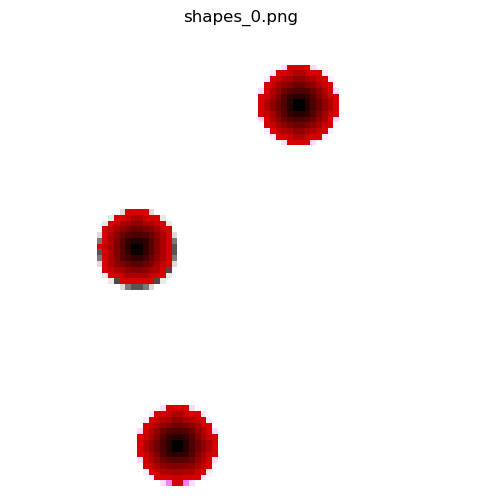

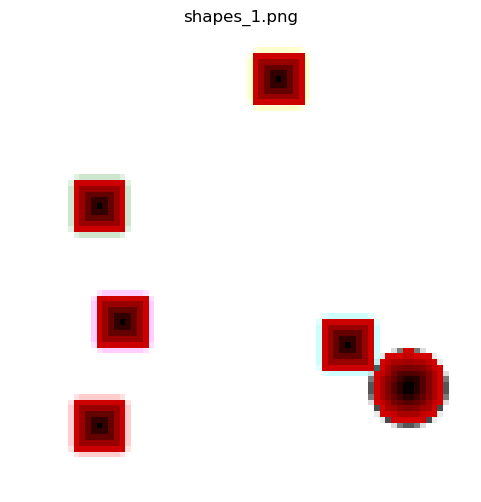

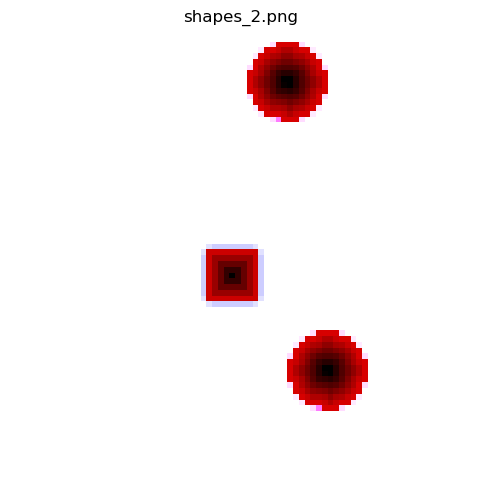

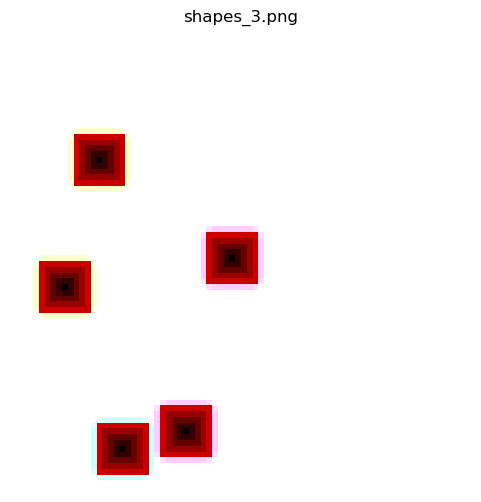

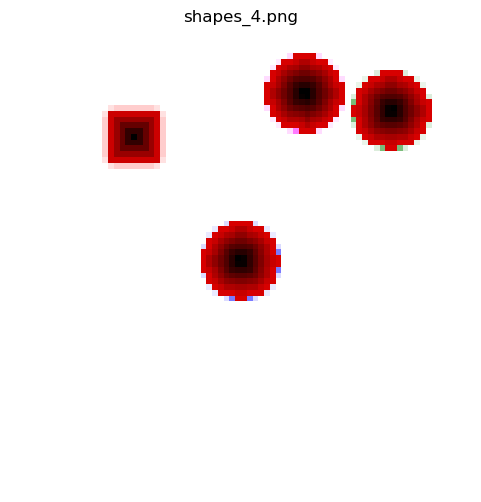

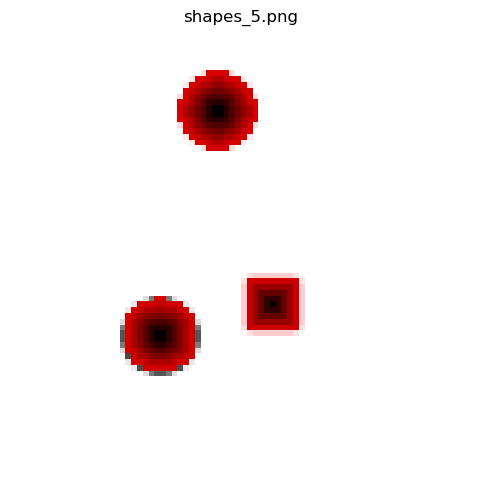

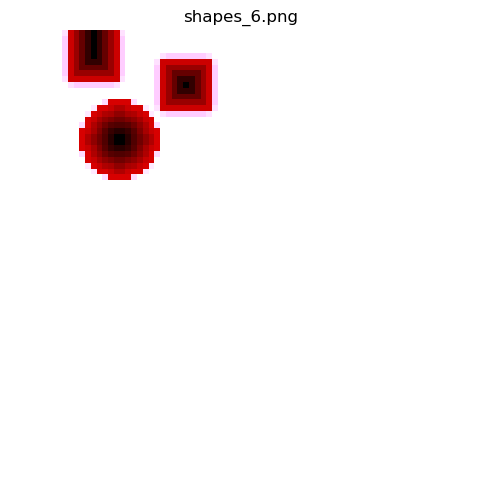

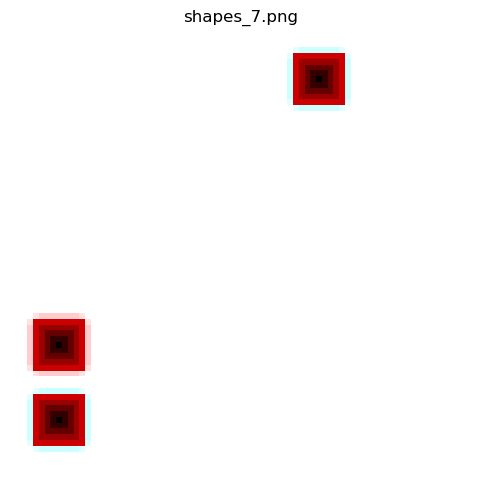

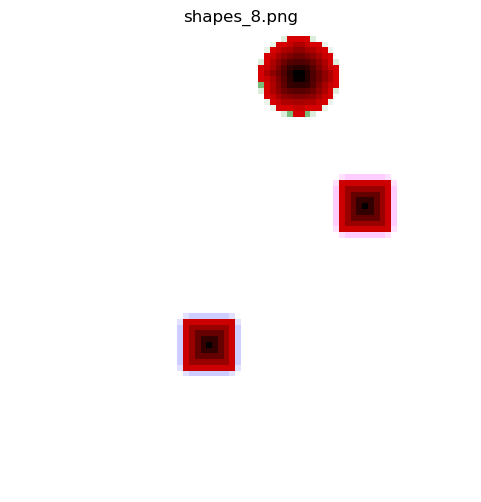

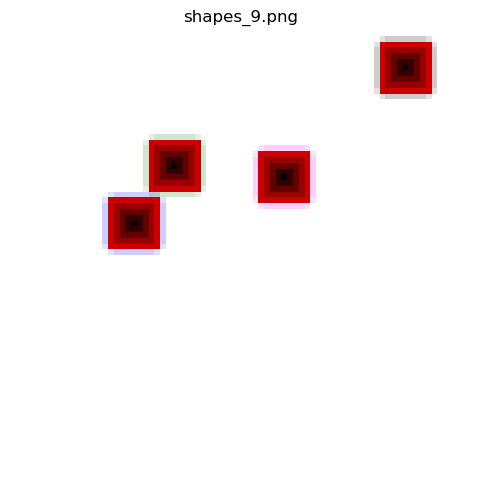

In [14]:
#step8: Visualize the New Segmentation Masks (Optional)
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

def fill_poly_with_ombre(image, poly, base_color=(255, 0, 0)):
    """
    Fill the polygon defined by `poly` with an ombre effect.
    The effect is computed using a distance transform so that the border 
    is at full intensity and it fades toward the center.
    """
    # Create a binary mask for the polygon.
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    poly_np = np.array(poly).reshape((-1, 2)).astype(np.int32)
    cv2.fillPoly(mask, [poly_np], 255)
    
    # Compute the distance transform: distance of each pixel in the polygon to the nearest edge.
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    
    # Normalize distances to [0,1]
    if np.max(dist) > 0:
        norm = dist / np.max(dist)
    else:
        norm = dist
    
    # Create an intensity map: full intensity at the border (norm=0) and fading towards the center.
    intensity = 1 - norm
    
    # Build an overlay: each channel is the base_color scaled by the intensity.
    overlay = np.zeros_like(image, dtype=np.uint8)
    for i in range(3):
        overlay[:,:,i] = (base_color[i] * intensity).astype(np.uint8)
    
    # Update only the pixels within the polygon.
    result = image.copy()
    result[mask == 255] = overlay[mask == 255]
    return result

def visualize_coco_segmentation_ombre(coco_path, images_dir, base_color=(255, 0, 0)):
    """
    Load the updated COCO annotations, apply the ombre effect to each segmentation polygon,
    and display the resulting image.
    """
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    
    # Map image_id to its list of annotations.
    ann_dict = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        ann_dict.setdefault(image_id, []).append(ann)
    
    # Process each image.
    for img_info in coco_data['images']:
        image_id = img_info['id']
        file_name = img_info['file_name']
        image_path = os.path.join(images_dir, file_name)
        
        img = cv2.imread(image_path)
        if img is None:
            print("Failed to load:", image_path)
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Apply the ombre fill for each segmentation polygon.
        for ann in ann_dict.get(image_id, []):
            for poly in ann.get("segmentation", []):
                if len(poly) < 6:  # Ensure valid polygon
                    continue
                img = fill_poly_with_ombre(img, poly, base_color)
        
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(file_name)
        plt.axis('off')
        plt.show()

# Usage for Step 8:
dataset_dir = "/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80"
coco_path = os.path.join(dataset_dir, "coco_annotations_with_masks.json")
images_dir = os.path.join(dataset_dir, "images")
visualize_coco_segmentation_ombre(coco_path, images_dir, base_color=(255, 0, 0))

In [11]:
# Step 9: Visualize original img with bbox vs. the New Segmentation Masks 
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_comparison_coco_ombre(coco_path, images_dir, base_color=(255, 0, 0)):
    """
    Displays a side-by-side comparison for each image:
      - Left: Original image with bounding boxes.
      - Right: Image with segmentation regions filled using an ombre effect.
    """
    with open(coco_path, 'r') as f:
        coco_data = json.load(f)
    
    # Map image_id to its annotations.
    ann_dict = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        ann_dict.setdefault(image_id, []).append(ann)
    
    # Process each image.
    for img_info in coco_data['images']:
        image_id = img_info['id']
        file_name = img_info['file_name']
        image_path = os.path.join(images_dir, file_name)
        
        img = cv2.imread(image_path)
        if img is None:
            print("Failed to load:", image_path)
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Create a copy for drawing bounding boxes.
        img_bbox = img.copy()
        anns = ann_dict.get(image_id, [])
        for ann in anns:
            bbox = ann.get("bbox", None)
            if bbox is not None:
                # bbox format: [x, y, w, h]
                x, y, w, h = bbox
                cv2.rectangle(img_bbox, (int(x), int(y)), (int(x+w), int(y+h)), color=(255, 0, 0), thickness=0)
        
        # Create a copy for the ombre segmentation overlay.
        img_ombre = img.copy()
        for ann in anns:
            for poly in ann.get("segmentation", []):
                if len(poly) < 6:
                    continue
                img_ombre = fill_poly_with_ombre(img_ombre, poly, base_color)
        
        # Display side-by-side comparison.
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(img_bbox)
        axs[0].set_title("Original with Bounding Box")
        axs[0].axis('off')
        
        axs[1].imshow(img_ombre)
        axs[1].set_title("SAM Ombre Segmentation Overlay")
        axs[1].axis('off')
        
        plt.show()

# Usage for Step 9:
visualize_comparison_coco_ombre(coco_path, images_dir, base_color=(255, 0, 0))

NameError: name 'coco_path' is not defined

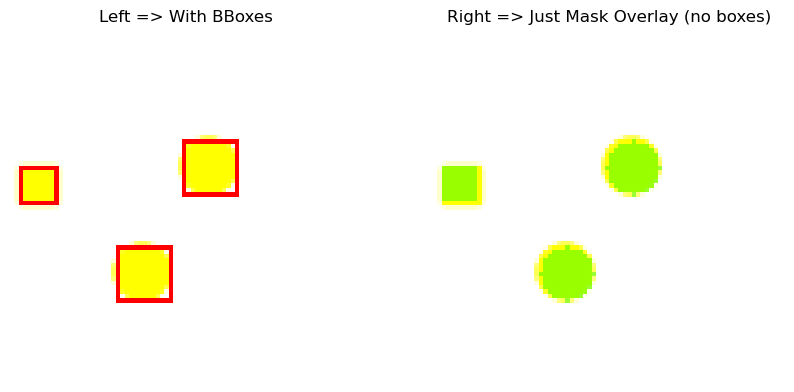

[INFO] Dataset size: 50


In [11]:
# step10: DEFINING SHAPES DATASET (BBOX->MASK) AND VISUAL CHECK

import torch
import numpy as np
import cv2
import os
import json
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

def overlay_mask_on_image(img_np, mask_bin, color=(255,0,0), alpha=0.5):
    """
    Overlays a semitransparent color on the image where mask_bin==1.
    img_np: [H,W,3] in RGB
    mask_bin: [H,W] in {0,1}
    color: (R,G,B) or (B,G,R)
    alpha: transparency factor. 0 => fully original, 1 => fully color
    """
    overlay = img_np.copy()
    color_arr = np.array(color, dtype=np.uint8)
    overlay[mask_bin == 1] = (
        alpha * color_arr + (1 - alpha) * overlay[mask_bin == 1]
    ).astype(np.uint8)
    return overlay

class ShapesSegmentationDataset(Dataset):
    """
    Multi-shape version:
      - Each image may have N shapes.
      - One item = (img_tensor, boxes_tensor, masks_tensor).
      - len(dataset) = number of image files.
      - boxes_tensor shape => [N,4]
      - masks_tensor shape => [N,H,W]
    """
    def __init__(self, images_dir, labels_dir, transform=None):
        super().__init__()
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        # Gather PNG image files
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
        # Gather JSON label files
        self.label_files = sorted([f for f in os.listdir(labels_dir) if f.endswith(".json")])
        
        assert len(self.image_files) == len(self.label_files), (
            f"Mismatch in image vs. label count: {len(self.image_files)} vs {len(self.label_files)}"
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1) Load image
        img_file = self.image_files[idx]
        lab_file = self.label_files[idx]
        img_path = os.path.join(self.images_dir, img_file)
        lab_path = os.path.join(self.labels_dir, lab_file)

        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise FileNotFoundError(f"Could not load {img_path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h_img, w_img = img_rgb.shape[:2]

        # Convert to torch
        img_tensor = torch.from_numpy(img_rgb).permute(2,0,1).float() / 255.0

        # 2) Load JSON shapes
        with open(lab_path, "r") as jf:
            ann_data = json.load(jf)  # e.g. [{object, x, y, w, h}, ...]

        boxes_list = []
        masks_list = []
        for shape_dict in ann_data:
            x = shape_dict['x']
            y = shape_dict['y']
            W = shape_dict['w']
            H = shape_dict['h']
            x1, y1 = x, y
            x2, y2 = x + W, y + H
            boxes_list.append([x1, y1, x2, y2])

            # Build mask
            mask = np.zeros((h_img, w_img), dtype=np.uint8)
            if shape_dict['object'] == 'rect':
                mask[y:y+H, x:x+W] = 1
            elif shape_dict['object'] == 'circle':
                r = int(round(W / 2.0))
                cx = x + r
                cy = y + r
                Y, X = np.ogrid[:h_img, :w_img]
                dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
                mask[dist <= r] = 1

            masks_list.append(mask)

        # Convert lists => Tensors
        boxes_tensor = torch.tensor(boxes_list, dtype=torch.float32)  # [N,4]
        masks_array = np.stack(masks_list, axis=0)  # => [N,H,W]
        masks_tensor = torch.from_numpy(masks_array).float()          # => [N,H,W]

        return img_tensor, boxes_tensor, masks_tensor

def visualize_dataset_item(dataset, idx=0):
    """
    Displays the entire image in the left panel (optionally with bounding boxes),
    and on the right panel an overlay *without* bounding boxes—just union mask.
    """
    img_tensor, boxes_tensor, masks_tensor = dataset[idx]
    img_np = (img_tensor.numpy() * 255).astype(np.uint8)
    img_np = np.transpose(img_np, (1,2,0))  # shape [H,W,3]

    # Build the union of all shapes
    union_mask = masks_tensor.sum(dim=0).clamp(max=1).numpy().astype(np.uint8)

    # If you *do* want to see bounding boxes on the left:
    img_with_boxes = img_np.copy()
    for (x1, y1, x2, y2) in boxes_tensor.int().tolist():
        cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), (255, 0, 0), 1)

    # Overlays a transparent color for the union mask
    overlay_np = overlay_mask_on_image(img_np, union_mask, color=(0,255,0), alpha=0.4)

    fig, axs = plt.subplots(1,2, figsize=(10, 5))
    axs[0].imshow(img_with_boxes)
    axs[0].set_title("Left => With BBoxes")
    axs[0].axis('off')

    axs[1].imshow(overlay_np)
    axs[1].set_title("Right => Just Mask Overlay (no boxes)")
    axs[1].axis('off')
    plt.show()

# --------------------------------------------------------------------
# Usage example
DATASET_IMAGES = "/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/images"
DATASET_LABELS = "/home/maryam_s/Documents/GPU SAM/segment_anything/notebooks/shapes/shapes_dataset_80x80_50imgs/labels_json"

shapes_dataset = ShapesSegmentationDataset(DATASET_IMAGES, DATASET_LABELS)

visualize_dataset_item(shapes_dataset, idx=0)
print(f"[INFO] Dataset size: {len(shapes_dataset)}")


In [ ]:
# step11: FULL TRAINING with bounding box prompt -> real predicted mask
# (Using 3 GPUs via DataParallel & detailed comments)

import torch
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

###############################################################################
# 0) ASSUME model_small AND shapes_dataset ARE ALREADY DEFINED
###############################################################################
# e.g. from step4.2 or a checkpoint load:
# model_small = ...
# from step10:
# shapes_dataset = ...
# device = "cuda" if torch.cuda.is_available() else "cpu"

# Just confirm they're defined:
try:
    model_small
except NameError:
    raise RuntimeError(
        "model_small is not defined. Please run your model build cell or checkpoint load first."
    )

try:
    shapes_dataset
except NameError:
    raise RuntimeError(
        "shapes_dataset is not defined. Please build it in step10 first."
    )

###############################################################################
# 1) CREATE A DATA LOADER
###############################################################################
# If shapes_dataset is multi-shape per image:
#   - batch_size=1 => each batch is 1 entire image & all shapes
# If single-shape items, adjust accordingly.
train_loader = DataLoader(shapes_dataset, batch_size=1, shuffle=True)

###############################################################################
# 2) CHOOSE YOUR UNFREEZING STRATEGY
###############################################################################
# Option A) Full fine-tuning of classical layers:
 
#   for name, param in model_small.image_encoder.named_parameters():
#       param.requires_grad = True
#   print("[TRAIN] => Full fine-tuning of classical + quantum.")

# Option B) Partial fine-tuning: only the last few blocks in image encoder.
#  E.g., unfreeze last 2 blocks, plus partial_q.
#   for idx, blk in enumerate(model_small.image_encoder.blocks):
#       # If total #blocks is e.g. depth=32, last 2 blocks => index >= 30
#       if idx < (len(model_small.image_encoder.blocks) - 2):
#           for p in blk.parameters():
#               p.requires_grad = False
#       else:
#           for p in blk.parameters():
#               p.requires_grad = True
#   # Also ensure partial_q is still trainable
#   for name, param in model_small.image_encoder.named_parameters():
#       if "partial_q" in name:
#           param.requires_grad = True
#   print("[TRAIN] => Unfreezing the last 2 blocks + partial_q only.")

# Option C) Unfreeze only normalizations + partial_q:
#   for name, param in model_small.image_encoder.named_parameters():
#       # if "norm" in name or "LayerNorm" or "partial_q" in name:
#       if "norm" in name or "partial_q" in name:
#           param.requires_grad = True
#       else:
#           param.requires_grad = False
#   print("[TRAIN] => Only normalizations + partial_q are trainable.")

#  --- UNCOMMENT the strategy you want. For an example, let's do Option B.

# -----------------------------------------
# Example: Option B partial unfreeze (last 2 blocks + partial_q).
# -----------------------------------------
for name, param in model_small.image_encoder.named_parameters():
    param.requires_grad = True
print("[TRAIN] => Full fine-tuning of classical + quantum.")


###############################################################################
# 3) WRAP IN DATAPARALLEL FOR 3 GPUS
###############################################################################
print("[TRAIN] Using DataParallel on model_small across GPUs [0,1,2].")
model_small = torch.nn.DataParallel(model_small, device_ids=[0,1,2])
device = "cuda" if torch.cuda.is_available() else "cpu"
model_small.to(device)  # put DP model on GPU(s)

###############################################################################
# 4) BUILD OPTIMIZER ON UNFROZEN (TRAINABLE) PARAMETERS
###############################################################################
trainable_params = [p for p in model_small.parameters() if p.requires_grad]
print(f"[TRAIN] Number of trainable params: {sum(p.numel() for p in trainable_params)}")

optimizer = optim.Adam(trainable_params, lr=1e-4)
print("[TRAIN] Using Adam, lr=1e-4")

###############################################################################
# 5) MEASURE INITIAL PARTIAL QUANTUM PARAM NORM
###############################################################################
init_q_param_norm = 0.0
for name, p in model_small.module.named_parameters():
    if "partial_q" in name:
        init_q_param_norm += p.norm().item()
print(f"[TRAIN] initial partial_q param norm = {init_q_param_norm:.4f}")

###############################################################################
# 6) DEFINE DICE LOSS FUNCTION
###############################################################################
def dice_loss(pred_masks, gt_masks):
    """
    pred_masks: shape [B, #, H, W], or [B,1,H,W].
    We'll assume [B,1,H,W].
    """
    B = pred_masks.size(0)
    pred = pred_masks.view(B, -1)  # flatten each item
    gt   = gt_masks.view(B, -1)
    intersection = (pred * gt).sum(dim=1)
    eps = 1e-6
    dice = (2.0 * intersection + eps) / (pred.sum(dim=1) + gt.sum(dim=1) + eps)
    return 1.0 - dice.mean()

###############################################################################
# 7) TRAINING LOOP
###############################################################################
num_epochs = 5
print(f"[TRAIN] Starting training for {num_epochs} epochs...")

model_small.module.train()  # set the underlying model to train

for epoch in range(num_epochs):
    print(f"\n=== EPOCH {epoch+1}/{num_epochs} ===")
    epoch_loss = 0.0
    count = 0

    for batch_data in train_loader:
        # shapes_dataset might produce (img_tensor, boxes_tensor, masks_tensor)
        # => [1,3,H,W], [1,N,4], [1,N,H,W]
        # adjust if your dataset is different
        img_tensor, boxes_tensor, masks_tensor = batch_data

        # move to device
        img_tensor = img_tensor.to(device)
        boxes_tensor = boxes_tensor.to(device)
        masks_tensor = masks_tensor.to(device)

        optimizer.zero_grad()

        # Typically shapes_dataset has 1 image at a time => squeeze(0)
        img_tensor = img_tensor.squeeze(0)        # [3,H,W]
        boxes_tensor = boxes_tensor.squeeze(0)    # [N,4]
        masks_tensor = masks_tensor.squeeze(0)    # [N,H,W]

        # 1) IMAGE ENCODER
        image_embeddings = model_small.module.image_encoder(img_tensor.unsqueeze(0))
        # => [1,256,H',W']

        # We'll accumulate shape-wise losses
        shape_losses = []
        N = boxes_tensor.shape[0]
        for i in range(N):
            one_box = boxes_tensor[i].unsqueeze(0)  # => [1,4]
            mask_gt = masks_tensor[i]               # => [H,W]

            # 2) PROMPT ENCODER
            sparse_emb, dense_emb = model_small.module.prompt_encoder(
                points=None,
                boxes=one_box,
                masks=None
            )
            # 3) MASK DECODER
            pred_masks, iou_preds = model_small.module.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=model_small.module.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_emb,
                dense_prompt_embeddings=dense_emb,
                multimask_output=False
            )
            # => [1,1,H',W']

            # upsample
            b_out, c_out, h_dec, w_dec = pred_masks.shape
            mask_h, mask_w = mask_gt.shape
            pred_upsampled = F.interpolate(
                pred_masks, (mask_h, mask_w), mode='bilinear', align_corners=False
            )  # => [1,1,mask_h,mask_w]
            pred_upsampled = pred_upsampled.squeeze(0)  # => [1,mask_h,mask_w]

            # 4) dice loss
            loss_shape = dice_loss(
                pred_upsampled,
                mask_gt.unsqueeze(0).unsqueeze(0)
            )
            shape_losses.append(loss_shape)

        if len(shape_losses) > 0:
            loss = torch.stack(shape_losses).mean()
        else:
            loss = torch.tensor(0.0, device=device)

        # BACKPROP
        loss.backward()

        # Debug partial_q grads
        for name, param in model_small.module.named_parameters():
            if "partial_q" in name:
                if param.grad is not None:
                    g_mean = param.grad.mean().item()
                    g_min = param.grad.min().item()
                    g_max = param.grad.max().item()
                    print(f"[DEBUG] {name} grad => mean={g_mean:.6f},"
                          f" min={g_min:.6f}, max={g_max:.6f}")
                else:
                    print(f"[DEBUG] {name} grad is None -> no gradient.")

        optimizer.step()

        epoch_loss += loss.item()
        count += 1

    avg_loss = epoch_loss / max(count,1)
    print(f"[TRAIN] EPOCH {epoch+1}/{num_epochs}, loss={avg_loss:.4f}")

###############################################################################
# 8) CHECK FINAL PARTIAL Q PARAM NORM
###############################################################################
final_q_param_norm = 0.0
for name, p in model_small.module.named_parameters():
    if "partial_q" in name:
        final_q_param_norm += p.norm().item()
print(f"[TRAIN] partial_q param norm => init={init_q_param_norm:.4f}"
      f" => final={final_q_param_norm:.4f}")

###############################################################################
# 9) SAVE THE MODEL
###############################################################################
save_path = "trained_partial_q_v2.pth"
torch.save(model_small.module.state_dict(), save_path)
print(f"[TRAIN] Model saved to: {save_path}")

[TRAIN] => Full fine-tuning of classical + quantum.
[TRAIN] Using DataParallel on model_small across GPUs [0,1,2].
[TRAIN] Number of trainable params: 635804232
[TRAIN] Using Adam, lr=1e-4
[TRAIN] initial partial_q param norm = 0.0489
[TRAIN] Starting training for 5 epochs...

=== EPOCH 1/5 ===
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 5, 5, 1280])
[DEBUG] x_sub shape = torch.Size([1, 5, 5, 256]), x_rem shape = torch.Size([1, 5, 5, 1024])
Dense positional encoding shape: torch.Size([1, 256, 5, 5])
Shape of src (image embeddings): torch.Size([1, 256, 5, 5])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Stats of src: min = -0.5815465450286865 max = 0.48602890968322754 mean = -0.004069459158927202
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 25, 256])
Upscaled embedding shape: torch.Size([1, 32, 20, 20])
Hyper n

[DEBUG] image_encoder.partial_q.params grad => mean=0.000000, min=-0.000004, max=0.000010
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 5, 5, 1280])
[DEBUG] x_sub shape = torch.Size([1, 5, 5, 256]), x_rem shape = torch.Size([1, 5, 5, 1024])
Dense positional encoding shape: torch.Size([1, 256, 5, 5])
Shape of src (image embeddings): torch.Size([1, 256, 5, 5])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Stats of src: min = -0.517276406288147 max = 0.6448570489883423 mean = -0.003337037982419133
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 25, 256])
Upscaled embedding shape: torch.Size([1, 32, 20, 20])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 20, 20]) min = -40.588626861572266 max = -3.4641025066375732 mean = -19.084049224853516
Dense positional encodin

[DEBUG] image_encoder.partial_q.params grad => mean=-0.000000, min=-0.000009, max=0.000003
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 5, 5, 1280])
[DEBUG] x_sub shape = torch.Size([1, 5, 5, 256]), x_rem shape = torch.Size([1, 5, 5, 1024])
Dense positional encoding shape: torch.Size([1, 256, 5, 5])
Shape of src (image embeddings): torch.Size([1, 256, 5, 5])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Stats of src: min = -0.44963377714157104 max = 0.46604445576667786 mean = -0.0005080649279989302
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 25, 256])
Upscaled embedding shape: torch.Size([1, 32, 20, 20])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 20, 20]) min = -206.1386260986328 max = -12.75097370147705 mean = -38.95543670654297
Dense positional encod

[DEBUG] image_encoder.partial_q.params grad => mean=-0.000000, min=-0.000012, max=0.000007
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 5, 5, 1280])
[DEBUG] x_sub shape = torch.Size([1, 5, 5, 256]), x_rem shape = torch.Size([1, 5, 5, 1024])
Dense positional encoding shape: torch.Size([1, 256, 5, 5])
Shape of src (image embeddings): torch.Size([1, 256, 5, 5])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Stats of src: min = -0.4613969922065735 max = 0.44117262959480286 mean = -0.002497361972928047
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 25, 256])
Upscaled embedding shape: torch.Size([1, 32, 20, 20])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 20, 20]) min = -452.15826416015625 max = -2.1315555572509766 mean = -30.024871826171875
Dense positional enco

[DEBUG] image_encoder.partial_q.params grad => mean=0.000003, min=-0.000033, max=0.000071
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 5, 5, 1280])
[DEBUG] x_sub shape = torch.Size([1, 5, 5, 256]), x_rem shape = torch.Size([1, 5, 5, 1024])
Dense positional encoding shape: torch.Size([1, 256, 5, 5])
Shape of src (image embeddings): torch.Size([1, 256, 5, 5])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Stats of src: min = -0.45436400175094604 max = 0.48865804076194763 mean = -0.003722882829606533
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 25, 256])
Upscaled embedding shape: torch.Size([1, 32, 20, 20])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 20, 20]) min = -14.750625610351562 max = 15.611551284790039 mean = -2.1205074787139893
Dense positional encod

[DEBUG] image_encoder.partial_q.params grad => mean=0.000000, min=-0.000000, max=0.000001
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 5, 5, 1280])
[DEBUG] x_sub shape = torch.Size([1, 5, 5, 256]), x_rem shape = torch.Size([1, 5, 5, 1024])
Dense positional encoding shape: torch.Size([1, 256, 5, 5])
Shape of src (image embeddings): torch.Size([1, 256, 5, 5])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Stats of src: min = -0.46952036023139954 max = 0.4638309180736542 mean = -0.0034346082247793674
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 25, 256])
Upscaled embedding shape: torch.Size([1, 32, 20, 20])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 20, 20]) min = -3.0499801635742188 max = 24.687076568603516 mean = 6.084848403930664
Dense positional encodin

[DEBUG] image_encoder.partial_q.params grad => mean=0.000000, min=-0.000000, max=0.000000
[DEBUG] PartialQuantumModule.forward called. Input shape = torch.Size([1, 5, 5, 1280])
[DEBUG] x_sub shape = torch.Size([1, 5, 5, 256]), x_rem shape = torch.Size([1, 5, 5, 1024])
Dense positional encoding shape: torch.Size([1, 256, 5, 5])
Shape of src (image embeddings): torch.Size([1, 256, 5, 5])
Shape of dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Shape of src after adding dense_prompt_embeddings: torch.Size([1, 256, 5, 5])
Stats of src: min = -0.4652872681617737 max = 0.442854106426239 mean = -0.0034527394454926252
Transformer output (hs) shape: torch.Size([1, 7, 256])
Transformer output src shape: torch.Size([1, 25, 256])
Upscaled embedding shape: torch.Size([1, 32, 20, 20])
Hyper network output (hyper_in) shape: torch.Size([1, 4, 32])
Raw mask logits shape: torch.Size([1, 4, 20, 20]) min = 0.27292442321777344 max = 35.67720413208008 mean = 11.732170104980469
Dense positional encoding 

In [ ]:
# step11.1: Evaluate the newly trained small partial-quantum model (from step4.2).
import sys
sys.path.insert(0, "/home/maryam_s/Documents/GPU SAM/segment_anything")

import torch
import torch.nn.functional as F
import numpy as np
import cv2
import time

from segment_anything.modeling.sam import Sam
from segment_anything.modeling.image_encoder import ImageEncoderViT
from segment_anything.modeling.prompt_encoder import PromptEncoder
from segment_anything.modeling.mask_decoder import MaskDecoder
from segment_anything.modeling.transformer import TwoWayTransformer
from segment_anything import SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"

print("[EVAL] step11.1: Building small partial-quantum model with interpolated pos_embed (as in step4.2) ...")

############################
# 1) REBUILD THE IMAGE ENCODER EXACTLY AS STEP4.2
############################
small_image_encoder_eval = ImageEncoderViT(
    img_size=80,        
    patch_size=16,
    in_chans=3,
    embed_dim=1280,
    depth=32,
    num_heads=16,
    mlp_ratio=4.0,
    out_chans=256,
    qkv_bias=True,
    use_abs_pos=True,
    use_rel_pos=True,
    window_size=14,
    global_attn_indexes=[7,15,23,31],

    # partial quantum
    use_partial_quantum=True,
    quantum_dim=256,  
    n_qubits=8,
    n_layers_q=1,
    quantum_device="lightning.qubit",
)

############################
# 2) BUILD PROMPT/MASK EXACTLY LIKE step4.2
############################
small_prompt_encoder_eval = PromptEncoder(
    embed_dim=256,
    image_embedding_size=(5, 5),  # new_size from step4.2
    input_image_size=(80,80),
    mask_in_chans=16,
)

small_twoway_eval = TwoWayTransformer(
    depth=2,
    embedding_dim=256,
    num_heads=8,
    mlp_dim=2048,
)

small_mask_decoder_eval = MaskDecoder(
    transformer_dim=256,
    transformer=small_twoway_eval,
    num_multimask_outputs=3,
)

############################
# 3) BUILD SAM
############################
model_small_eval = Sam(
    image_encoder=small_image_encoder_eval,
    prompt_encoder=small_prompt_encoder_eval,
    mask_decoder=small_mask_decoder_eval,
    pixel_mean=[123.675,116.28,103.53],
    pixel_std=[58.395,57.12,57.375],
)

model_small_eval.to(device)

############################
# 4) LOAD THE (TRAINED) PARTIAL QUANTUM CHECKPOINT
############################
TRAINED_PQ_CKPT_PATH = "trained_partial_q_v2.pth"  # e.g., your new .pth
print(f"[EVAL] Loading trained partial quantum checkpoint: {TRAINED_PQ_CKPT_PATH}")
state = torch.load(TRAINED_PQ_CKPT_PATH, map_location=device)

missing_unexp = model_small_eval.load_state_dict(state, strict=False)
print("[EVAL] Missing/Unexpected keys:", missing_unexp)

model_small_eval.eval()

# Debug: final pos_embed shape
pe = model_small_eval.image_encoder.pos_embed
if pe is not None:
    print("[DEBUG] final pos_embed shape =", pe.shape)
else:
    print("[DEBUG] pos_embed is None")

# Debug: show rel_pos shapes for each block
for i, blk in enumerate(model_small_eval.image_encoder.blocks):
    attn = blk.attn
    if getattr(attn, "use_rel_pos", False):
        print(f"[DEBUG] block {i} rel_pos_h shape =", attn.rel_pos_h.shape)
        print(f"[DEBUG] block {i} rel_pos_w shape =", attn.rel_pos_w.shape)

############################
# 5) (OPTIONAL) INSPECT QUANTUM PARAM COUNT
############################
trainable_params = [p for p in model_small_eval.parameters() if p.requires_grad]
n_total = sum(p.numel() for p in trainable_params)
n_q = 0
for name, p in model_small_eval.named_parameters():
    if p.requires_grad and ("partial_q" in name or "quantum" in name):
        n_q += p.numel()
ratio_q = 100.0 * (n_q / n_total) if n_total>0 else 0.0
print(f"[EVAL] #Trainable total = {n_total}, #Quantum = {n_q} ({ratio_q:.2f}%)")

############################
# 6) EVALUATION FUNCTION (Multi-shape)
############################
def evaluate_segmentation_multi_shape(model, dataset):
    """
    Evaluate on a dataset where each item => (img_tensor, boxes_tensor, masks_tensor).
      - img_tensor: [3,H,W]
      - boxes_tensor: [N,4]
      - masks_tensor: [N,H,W]
    We'll:
      - encode the image once,
      - loop over each shape bounding box to get predicted mask,
      - measure IoU/Dice vs. that shape's GT,
      - average across shapes in each image,
      - then average across images.
    """
    iou_list = []
    dice_list = []
    model.eval()

    for item_idx in range(len(dataset)):
        # Retrieve one image + all bounding boxes + all masks
        img_tensor, boxes_tensor, masks_tensor = dataset[item_idx]
        # shapes:
        #   img_tensor => [3,H,W]
        #   boxes_tensor => [N,4]
        #   masks_tensor => [N,H,W]

        # move image to device
        device_img = img_tensor.unsqueeze(0).to(device)  # => [1,3,H,W]

        # encode once per image
        with torch.no_grad():
            mod = model.module if isinstance(model, torch.nn.DataParallel) else model
            image_embeddings = mod.image_encoder(device_img)  # => [1,256,H',W']

        iou_per_image = []
        dice_per_image = []

        N = boxes_tensor.shape[0]
        H, W = img_tensor.shape[-2], img_tensor.shape[-1]

        for i in range(N):
            # bounding box => shape [1,1,4]
            one_box = boxes_tensor[i].unsqueeze(0).unsqueeze(0).to(device)
            # GT mask => shape [H,W]
            mask_gt = masks_tensor[i].numpy()

            with torch.no_grad():
                # prompt encoder
                sparse_emb, dense_emb = mod.prompt_encoder(
                    points=None,
                    boxes=one_box,
                    masks=None
                )
                # decode
                pred_masks, iou_preds = mod.mask_decoder(
                    image_embeddings=image_embeddings,
                    image_pe=mod.prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sparse_emb,
                    dense_prompt_embeddings=dense_emb,
                    multimask_output=False
                )
                # => shape [1,1,H',W']

                # upsample back to original size
                pred_upsampled = F.interpolate(
                    pred_masks,
                    size=(H,W),
                    mode='bilinear',
                    align_corners=False
                )
                # => [1,1,H,W]
                pred_bin = (pred_upsampled>0.5).float().cpu().numpy()
                # shape => [1,1,H,W]
                pred_bin = pred_bin.squeeze(0).squeeze(0)  # => [H,W]

            # measure IoU, Dice
            intersection = np.logical_and(pred_bin, mask_gt).sum()
            union = np.logical_or(pred_bin, mask_gt).sum()
            iou_val = intersection/union if union>0 else 0
            dice_val = (2*intersection)/(pred_bin.sum()+mask_gt.sum()) if (pred_bin.sum()+mask_gt.sum())>0 else 0

            iou_per_image.append(iou_val)
            dice_per_image.append(dice_val)

        # average across shapes in this image
        if len(iou_per_image)>0:
            iou_list.append( np.mean(iou_per_image) )
            dice_list.append( np.mean(dice_per_image) )
        else:
            # edge case: no shapes => skip
            pass

    # final average across images
    mean_iou = float(np.mean(iou_list)) if iou_list else 0
    mean_dice = float(np.mean(dice_list)) if dice_list else 0
    print(f"[EVAL] Over {len(dataset)} images => IoU={mean_iou:.3f}, Dice={mean_dice:.3f}")
    return mean_iou, mean_dice

############################
# 7) RUN EVAL
############################
print("[EVAL] Let's run segmentation evaluation on shapes_dataset ...")
# call our multi-shape evaluation
evaluate_segmentation_multi_shape(model_small_eval, shapes_dataset)

print("[EVAL] Finished evaluation.")

In [ ]:
temp = torch.load("trained_partial_q_v2.pth", map_location="cpu")
print("=> from checkpoint pos_embed shape = ",
      temp["image_encoder.pos_embed"].shape)

In [ ]:
# step12_visualize_predictions.py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import cv2

def visualize_model_predictions(model, dataset, num_samples=3, device="cuda"):
    """
    We'll pick some sample images from 'dataset'.
    For each image:
     - get all shapes (boxes + GT masks),
     - run the model for each box prompt,
     - upsample the predicted mask,
     - overlay onto original image,
     - show side by side.
    """
    model.eval()
    model = model.to(device)  # Ensure the model is on the same device

    for idx in range(num_samples):
        img_tensor, boxes_tensor, masks_tensor = dataset[idx]
        # Move them to device
        img_tensor = img_tensor.to(device)
        boxes_tensor = boxes_tensor.to(device)
        masks_tensor = masks_tensor.to(device)
        
        H, W = img_tensor.shape[-2], img_tensor.shape[-1]
        # Convert image to CPU numpy for visualization
        img_np = (img_tensor.detach().cpu().numpy() * 255).astype(np.uint8)
        img_np = np.transpose(img_np, (1,2,0))  # => [H,W,3], still in RGB

        # 1) Encode image
        with torch.no_grad():
            image_embeddings = model.image_encoder(img_tensor.unsqueeze(0))  # shape [1,256,H',W']

        # We'll build an overlay that accumulates predicted masks for all shapes
        overlay = img_np.copy()

        # 2) For each shape bounding box => predict mask
        n_shapes = boxes_tensor.shape[0]
        for i in range(n_shapes):
            one_box = boxes_tensor[i].unsqueeze(0)  # => shape [1,4]
            # prompt encoder
            with torch.no_grad():
                sparse_emb, dense_emb = model.prompt_encoder(
                    points=None, boxes=one_box, masks=None
                )
                # mask decoder
                pred_masks, iou_preds = model.mask_decoder(
                    image_embeddings=image_embeddings,
                    image_pe=model.prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sparse_emb,
                    dense_prompt_embeddings=dense_emb,
                    multimask_output=False
                )
                # => pred_masks shape [1,1,H',W']

            # 3) Upsample predicted mask to original image resolution
            pred_upsampled = F.interpolate(
                pred_masks, size=(H, W),
                mode='bilinear', align_corners=False
            )
            # shape => [1,1,H,W]
            pred_bin = (pred_upsampled.squeeze(0).squeeze(0) > 0.5).float()
            pred_bin_np = pred_bin.detach().cpu().numpy().astype(np.uint8)

            # 4) Overlay predicted mask in green
            color = np.array([0,255,0], dtype=np.uint8)
            alpha = 0.4
            overlay[pred_bin_np==1] = (
                alpha*color + (1-alpha)*overlay[pred_bin_np==1]
            ).astype(np.uint8)

            # 5) Also draw the bounding box
            box_cpu = boxes_tensor[i].detach().cpu().numpy().astype(int)
            cv2.rectangle(overlay, (box_cpu[0], box_cpu[1]),
                                    (box_cpu[2], box_cpu[3]),
                          (255,0,0), 1)

        # 6) Show side-by-side
        fig, axs = plt.subplots(1,2, figsize=(10,5))
        axs[0].imshow(img_np)
        axs[0].set_title("Original Image (RGB)")
        axs[0].axis('off')

        axs[1].imshow(overlay)
        axs[1].set_title("Predicted Masks + Boxes")
        axs[1].axis('off')
        plt.show()

In [ ]:
 visualize_model_predictions(model_small_eval, shapes_dataset, num_samples=3)